## **Credit Risk Scoring using Decision Tree**

A binary classification model

Customer can pay the credit or be defaulted.

### **Data cleaning and preparation**

- Download the dataset
- Re-encode the categorical variables
- Train, validation and test split 

In [1]:
# data = "https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/refs/heads/master/chapter-06-trees/CreditScoring.csv"
# !wget $data

In [2]:
import pandas as pd
import numpy as np

df1 = pd.read_csv('CreditScoring.csv')
df1.head()

,Status,Seniority,Home,Time,Age,Marital,Records,Job,Expenses,Income,Assets,Debt,Amount,Price
0,1,9,1,60,30,2,1,3,73,129,0,0,800,846
1,1,17,1,60,58,3,1,1,48,131,0,0,1000,1658
2,2,10,2,36,46,2,2,3,90,200,3000,0,2000,2985
3,1,0,1,60,24,1,1,1,63,182,2500,0,900,1325
4,1,0,1,36,26,1,1,1,46,107,0,0,310,910


The dataset has been transformed and as much as we thank them for doing that right away, it is good to understand the transformation they did.

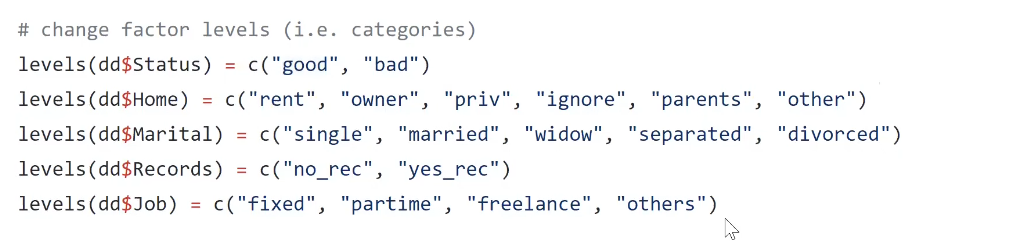

In [3]:
df = df1
df.columns = df.columns.str.lower()

In [4]:
df.status.value_counts()

status
1    3200
2    1254
0       1
Name: count, dtype: int64

In [5]:
df.status = df.status.map({1:'ok', 2:'default', 0:'unk'})

In [6]:
df.status.value_counts()

status
ok         3200
default    1254
unk           1
Name: count, dtype: int64

In [7]:
home_values = {
    1: 'rent',
    2: 'owner',
    3: 'private',
    4: 'ignore',
    5: 'parents',
    6: 'other',
    0: 'unk'
}
df.home = df.home.map(home_values)

marital_values = {
    1: 'single',
    2: 'married',
    3: 'widow',
    4: 'separated',
    5: 'divorced',
    0: 'unk'
}
df.marital = df.marital.map(marital_values)

records_values = {
    1: 'no',
    2: 'yes',
    0: 'unk'
}
df.records = df.records.map(records_values)


job_values = {
    1: 'fixed',
    2: 'partime',
    3: 'freelance',
    4: 'others',
    0: 'unk'
}
df.job = df.job.map(job_values)

Remove the unknown status. Status is very important for us because it is the dependent variable

In [8]:
df = df[df['status'] != 'unk'].reset_index(drop=True)

In [9]:
df

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,ok,9,rent,60,30,married,no,freelance,73,129,0,0,800,846
1,ok,17,rent,60,58,widow,no,fixed,48,131,0,0,1000,1658
2,default,10,owner,36,46,married,yes,freelance,90,200,3000,0,2000,2985
3,ok,0,rent,60,24,single,no,fixed,63,182,2500,0,900,1325
4,ok,0,rent,36,26,single,no,fixed,46,107,0,0,310,910
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4449,default,1,rent,60,39,married,no,fixed,69,92,0,0,900,1020
4450,ok,22,owner,60,46,married,no,fixed,60,75,3000,600,950,1263
4451,default,0,owner,24,37,married,no,partime,60,90,3500,0,500,963
4452,ok,0,rent,48,23,single,no,freelance,49,140,0,0,550,550


In [10]:
df.head()

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,ok,9,rent,60,30,married,no,freelance,73,129,0,0,800,846
1,ok,17,rent,60,58,widow,no,fixed,48,131,0,0,1000,1658
2,default,10,owner,36,46,married,yes,freelance,90,200,3000,0,2000,2985
3,ok,0,rent,60,24,single,no,fixed,63,182,2500,0,900,1325
4,ok,0,rent,36,26,single,no,fixed,46,107,0,0,310,910


In [11]:
df.describe()

,seniority,time,age,expenses,income,assets,debt,amount,price
count,4454.000000,4454.000000,4454.000000,4454.000000,4.454000e+03,4.454000e+03,4.454000e+03,4454.000000,4454.000000
mean,7.986753,46.438707,37.080377,55.573417,7.634883e+05,1.060578e+06,4.044728e+05,1038.918276,1462.780198
std,8.174306,14.655462,10.984598,19.515634,8.704595e+06,1.021870e+07,6.344963e+06,474.545999,628.128120
min,0.000000,6.000000,18.000000,35.000000,0.000000e+00,0.000000e+00,0.000000e+00,100.000000,105.000000
25%,2.000000,36.000000,28.000000,35.000000,8.000000e+01,0.000000e+00,0.000000e+00,700.000000,1117.250000
50%,5.000000,48.000000,36.000000,51.000000,1.200000e+02,3.500000e+03,0.000000e+00,1000.000000,1400.000000
75%,12.000000,60.000000,45.000000,72.000000,1.660000e+02,6.000000e+03,0.000000e+00,1300.000000,1691.500000
max,48.000000,72.000000,68.000000,180.000000,1.000000e+08,1.000000e+08,1.000000e+08,5000.000000,11140.000000


In [12]:
df.income.max()

np.int64(99999999)

According to the dataset dictionary, 99999999 means null. Thus, we have to change that too using replace

In [13]:
df.income = df.income.replace(to_replace=99999999, value=np.nan)
df.income.max()

np.float64(959.0)

do it to assets and debt too

In [14]:
for i in ['assets', 'debt']:
    df[i] = df[i].replace(to_replace=99999999, value=np.nan)

In [15]:
df.describe()

,seniority,time,age,expenses,income,assets,debt,amount,price
count,4454.000000,4454.000000,4454.000000,4454.000000,4420.000000,4407.000000,4436.000000,4454.000000,4454.000000
mean,7.986753,46.438707,37.080377,55.573417,130.564253,5403.979351,343.025924,1038.918276,1462.780198
std,8.174306,14.655462,10.984598,19.515634,86.376808,11574.418141,1245.991541,474.545999,628.128120
min,0.000000,6.000000,18.000000,35.000000,0.000000,0.000000,0.000000,100.000000,105.000000
25%,2.000000,36.000000,28.000000,35.000000,80.000000,0.000000,0.000000,700.000000,1117.250000
50%,5.000000,48.000000,36.000000,51.000000,120.000000,3000.000000,0.000000,1000.000000,1400.000000
75%,12.000000,60.000000,45.000000,72.000000,165.000000,6000.000000,0.000000,1300.000000,1691.500000
max,48.000000,72.000000,68.000000,180.000000,959.000000,300000.000000,30000.000000,5000.000000,11140.000000


#### **After pre-processing its about time to use sklearn train test split**

In [16]:
from sklearn.model_selection import train_test_split

df_full_train, df_test = train_test_split(df, test_size = 0.2, random_state = 11 )
df_train, df_val = train_test_split(df_full_train, test_size = 0.25, random_state = 11)

In [17]:
# Reset index
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

Converting the status back to numerical value

0 = ok
1 = default

In [18]:
df_train.status == 'default'

0        True
1        True
2       False
3        True
4       False
        ...  
2667    False
2668    False
2669    False
2670    False
2671    False
Name: status, Length: 2672, dtype: bool

In [19]:
(df_train.status == 'default').astype(int)

0       1
1       1
2       0
3       1
4       0
       ..
2667    0
2668    0
2669    0
2670    0
2671    0
Name: status, Length: 2672, dtype: int64

In [20]:
y_train = (df_train.status == 'default').astype(int).values
y_test = (df_test.status == 'default').astype(int).values
y_val = (df_val.status == 'default').astype(int).values
y_train

array([1, 1, 0, ..., 0, 0, 0], shape=(2672,))

In [21]:
del df_train['status']
del df_test['status']
del df_val['status']

## **Decision Trees**

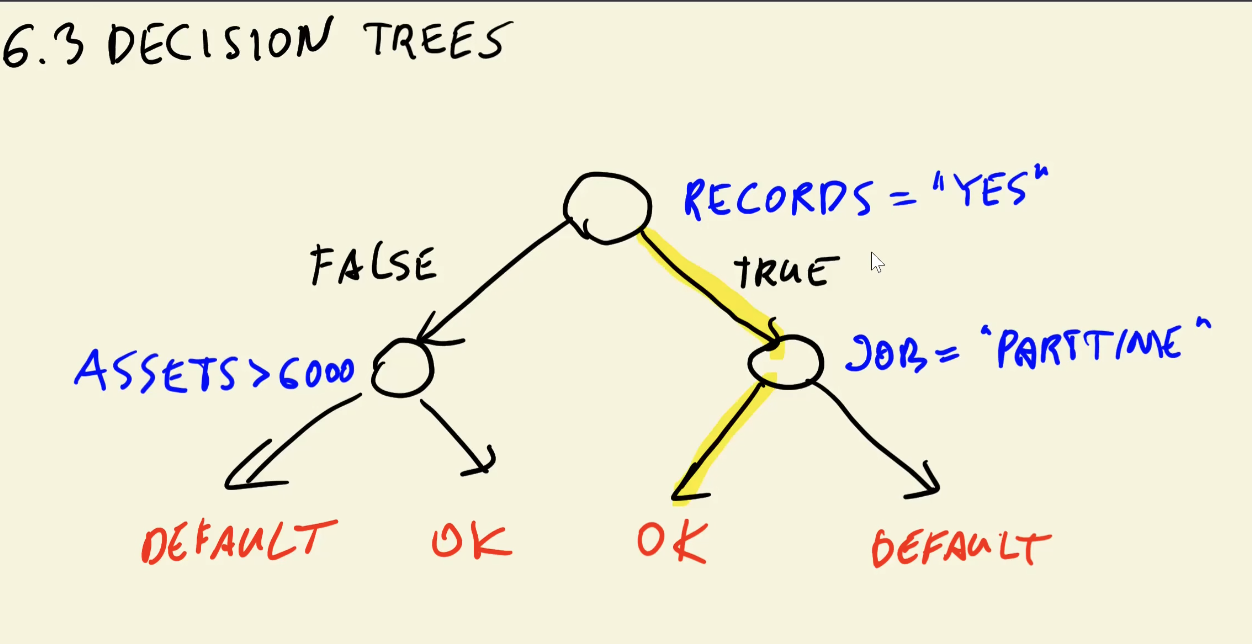

In [31]:
from sklearn.tree import DecisionTreeClassifier 
from sklearn.feature_extraction import DictVectorizer
from sklearn.metrics import roc_auc_score

1. Create the training dictionary 

In [23]:
df_train.isnull().sum()

seniority     0
home          0
time          0
age           0
marital       0
records       0
job           0
expenses      0
income       25
assets       30
debt         11
amount        0
price         0
dtype: int64

There are several null records, we don't want that. Instead lets fill them as 0 for the mean time. 

In [24]:
train_dicts = df_train.fillna(0).to_dict(orient='records')
train_dicts[0]

{'seniority': 10,
 'home': 'owner',
 'time': 36,
 'age': 36,
 'marital': 'married',
 'records': 'no',
 'job': 'freelance',
 'expenses': 75,
 'income': 0.0,
 'assets': 10000.0,
 'debt': 0.0,
 'amount': 1000,
 'price': 1400}

2. Create the vectorizer
3. Fit and transform the training dictionary to this vectorizer

In [25]:
dv = DictVectorizer(sparse=False)
X_train = dv.fit_transform(train_dicts)
X_train[0]

array([3.6e+01, 1.0e+03, 1.0e+04, 0.0e+00, 7.5e+01, 0.0e+00, 0.0e+00,
       1.0e+00, 0.0e+00, 0.0e+00, 0.0e+00, 0.0e+00, 0.0e+00, 0.0e+00,
       1.0e+00, 0.0e+00, 0.0e+00, 0.0e+00, 0.0e+00, 1.0e+00, 0.0e+00,
       0.0e+00, 0.0e+00, 0.0e+00, 1.4e+03, 1.0e+00, 0.0e+00, 1.0e+01,
       3.6e+01])

4. Exploring the features of the vectorizer

In [26]:
dv.get_feature_names_out()

array(['age', 'amount', 'assets', 'debt', 'expenses', 'home=ignore',
       'home=other', 'home=owner', 'home=parents', 'home=private',
       'home=rent', 'home=unk', 'income', 'job=fixed', 'job=freelance',
       'job=others', 'job=partime', 'job=unk', 'marital=divorced',
       'marital=married', 'marital=separated', 'marital=single',
       'marital=unk', 'marital=widow', 'price', 'records=no',
       'records=yes', 'seniority', 'time'], dtype=object)

5. Use the DecisionTreeClassifier to fit and transform the X_train 

In [27]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


6. Repeat the process to the validation dataset

In [28]:
df_train.isnull().sum()

seniority     0
home          0
time          0
age           0
marital       0
records       0
job           0
expenses      0
income       25
assets       30
debt         11
amount        0
price         0
dtype: int64

There are nulls in the

In [29]:
val_dicts = df_val.fillna(0).to_dict(orient='records')
X_val = dv.transform(val_dicts) # only use transform

Now used the model dt to predict the y of the X_val

In [34]:
y_pred = dt.predict_proba(X_val)[:, 1]

In [35]:
roc_auc_score(y_val, y_pred)

0.6529388970962196

The auc of 0.65 is not good. Now look at the auc of the model to further understand why the validation dataset only has 0.65 

In [36]:
y_pred = dt.predict_proba(X_train)[:, 1]
roc_auc_score(y_train, y_pred)

1.0

1.0! It's overfit. The model just memorized everything, and with this if there is a new values it will have a hard time to create prediction. It failed to generalize

#### **Depth**
- a very important parameter in Decision Trees. We dont have to have a numeriouus layers of decision

**Decision Stump** 
- 1 layer or depth = 1

In [37]:
dt = DecisionTreeClassifier(max_depth=3)
dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [40]:
y_pred = dt.predict_proba(X_train)[:,1]
roc_auc_score(y_train, y_pred)


0.7761016984958594

A better roc_auc_score for the model

In [42]:
y_pred = dt.predict_proba(X_val)[:,1]
roc_auc_score(y_val, y_pred)


0.7389079944782155

0.74 is a massive jump from 0.65 recently. Solution is to avoid overfitting by using max_depth parameter

In [44]:
from sklearn.tree import export_text
print(export_text(dt, feature_names=dv.get_feature_names_out()))

|--- records=no <= 0.50
|   |--- seniority <= 6.50
|   |   |--- amount <= 862.50
|   |   |   |--- class: 0
|   |   |--- amount >  862.50
|   |   |   |--- class: 1
|   |--- seniority >  6.50
|   |   |--- income <= 103.50
|   |   |   |--- class: 1
|   |   |--- income >  103.50
|   |   |   |--- class: 0
|--- records=no >  0.50
|   |--- job=partime <= 0.50
|   |   |--- income <= 74.50
|   |   |   |--- class: 0
|   |   |--- income >  74.50
|   |   |   |--- class: 0
|   |--- job=partime >  0.50
|   |   |--- assets <= 8750.00
|   |   |   |--- class: 1
|   |   |--- assets >  8750.00
|   |   |   |--- class: 0



Note: Remember during the dataset dictionary, 0 means yes while 1 means no

2 levels

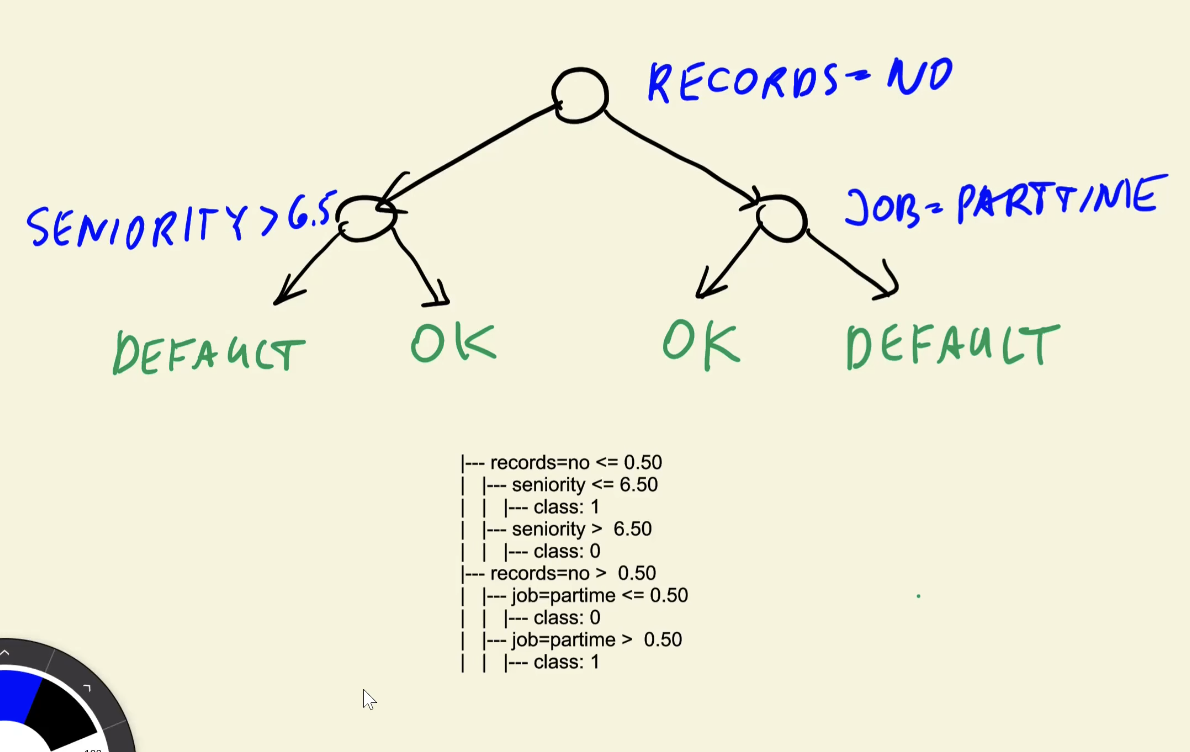

## **Decision Tree Algorithm**

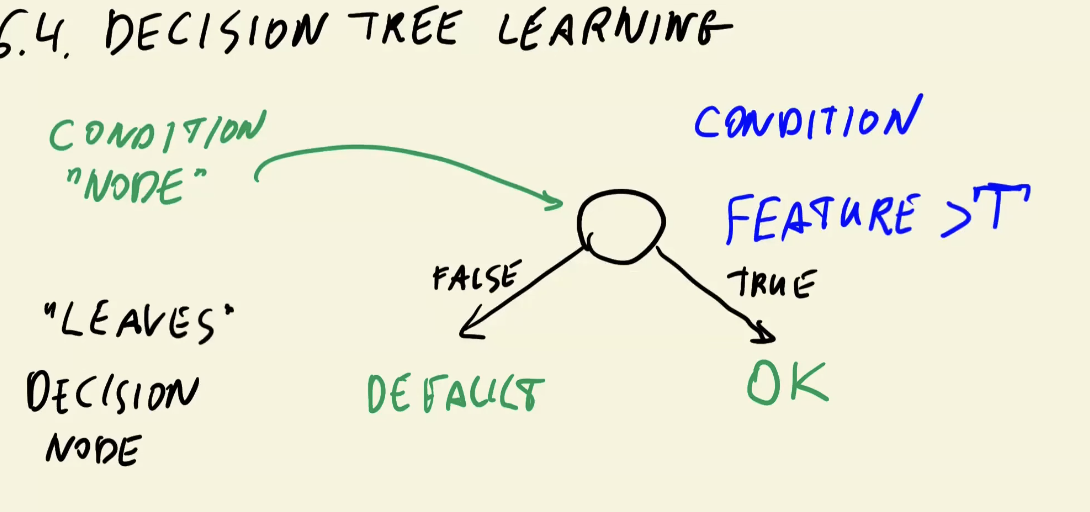

In [46]:
# Example dataset

data = [
[8000, 'default'],
[2000, 'default'],
[0, 'default'],
[5000, 'ok'],
[5000, 'ok'],
[4000, 'ok'],
[9000, 'ok'],
[7000, 'default']

]

df_example = pd.DataFrame(data, columns=['assets', 'status'])
df_example

,assets,status
0,8000,default
1,2000,default
2,0,default
3,5000,ok
4,5000,ok
5,4000,ok
6,9000,ok
7,7000,default


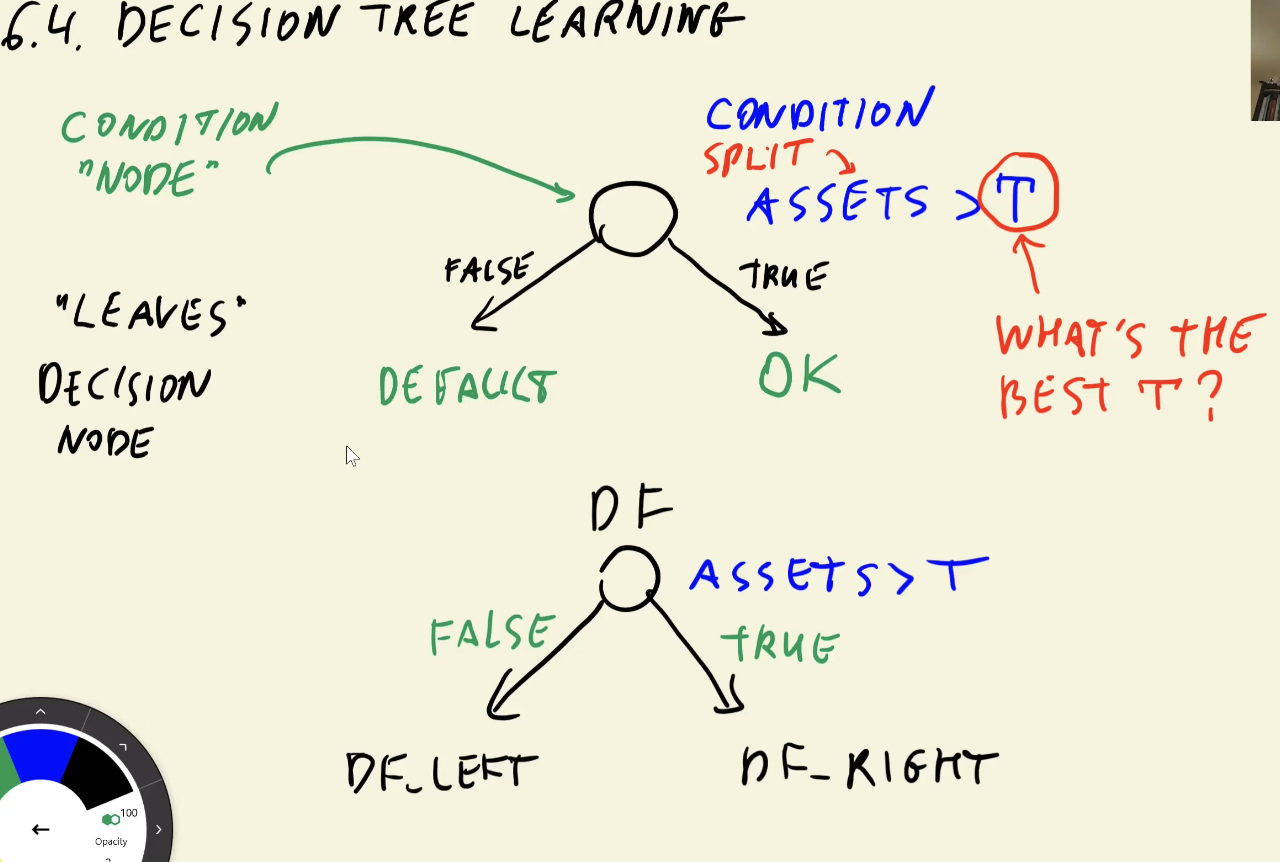

The main question is, what would be the best T or best threshold in order to split the dataframe to left or to the right

Looking at the df, the possible T are 2000,3000,4000,5000 and 8000. You cannot use 0 and 9000 because nothing will remain if you use them as threshold. (based on the dataset there is no <0 and there is no > 9000) 

In [55]:
# In order to display the df inside the for loops 
import IPython

In [54]:
Ts = [2000,3000,4000,5000 ,8000 ]

for i in Ts:
    print(i)
    df_left = df_example[df_example['assets'] <= i]
    df_right = df_example[df_example['assets'] > i]
    print()

    display(df_left)
    display(df_right)


2000



,assets,status
1,2000,default
2,0,default


,assets,status
0,8000,default
3,5000,ok
4,5000,ok
5,4000,ok
6,9000,ok
7,7000,default


3000



,assets,status
1,2000,default
2,0,default


,assets,status
0,8000,default
3,5000,ok
4,5000,ok
5,4000,ok
6,9000,ok
7,7000,default


4000



,assets,status
1,2000,default
2,0,default
5,4000,ok


,assets,status
0,8000,default
3,5000,ok
4,5000,ok
6,9000,ok
7,7000,default


5000



,assets,status
1,2000,default
2,0,default
3,5000,ok
4,5000,ok
5,4000,ok


,assets,status
0,8000,default
6,9000,ok
7,7000,default


8000



,assets,status
0,8000,default
1,2000,default
2,0,default
3,5000,ok
4,5000,ok
5,4000,ok
7,7000,default


,assets,status
6,9000,ok


Now through visual inspection, choose the best split for which there is a little to no error or misclassification

In [56]:
Ts = [4000 ]

for i in Ts:
    print(i)
    df_left = df_example[df_example['assets'] <= i]
    df_right = df_example[df_example['assets'] > i]
    print()

    display(df_left)
    display(df_right)


4000



,assets,status
1,2000,default
2,0,default
5,4000,ok


,assets,status
0,8000,default
3,5000,ok
4,5000,ok
6,9000,ok
7,7000,default


When the threshold is 4000:
df left will have 2 default 1 ok
df right will have 2 default 3 ok

- if df left will only have defaults, then it will have 1/3 (33%) misclassification rate

- if df right will only have ok, then it will have 2/5 (40%) misclassification rate 

If we use this threshold the **average misclassification rate** will be (40+33)/2 = 36.5% 

In [62]:
Ts = [4000 ]

for i in Ts:
    print(i)
    df_left = df_example[df_example['assets'] <= i]
    df_right = df_example[df_example['assets'] > i]

    print()

    display(df_left)
    print(df_left.status.value_counts(normalize=True))
    display(df_right)
    print(df_right.status.value_counts(normalize=True))

4000



,assets,status
1,2000,default
2,0,default
5,4000,ok


status
default    0.666667
ok         0.333333
Name: proportion, dtype: float64


,assets,status
0,8000,default
3,5000,ok
4,5000,ok
6,9000,ok
7,7000,default


status
ok         0.6
default    0.4
Name: proportion, dtype: float64


### **Misclassification rate == Impurity**
- creating a table to visualize it better

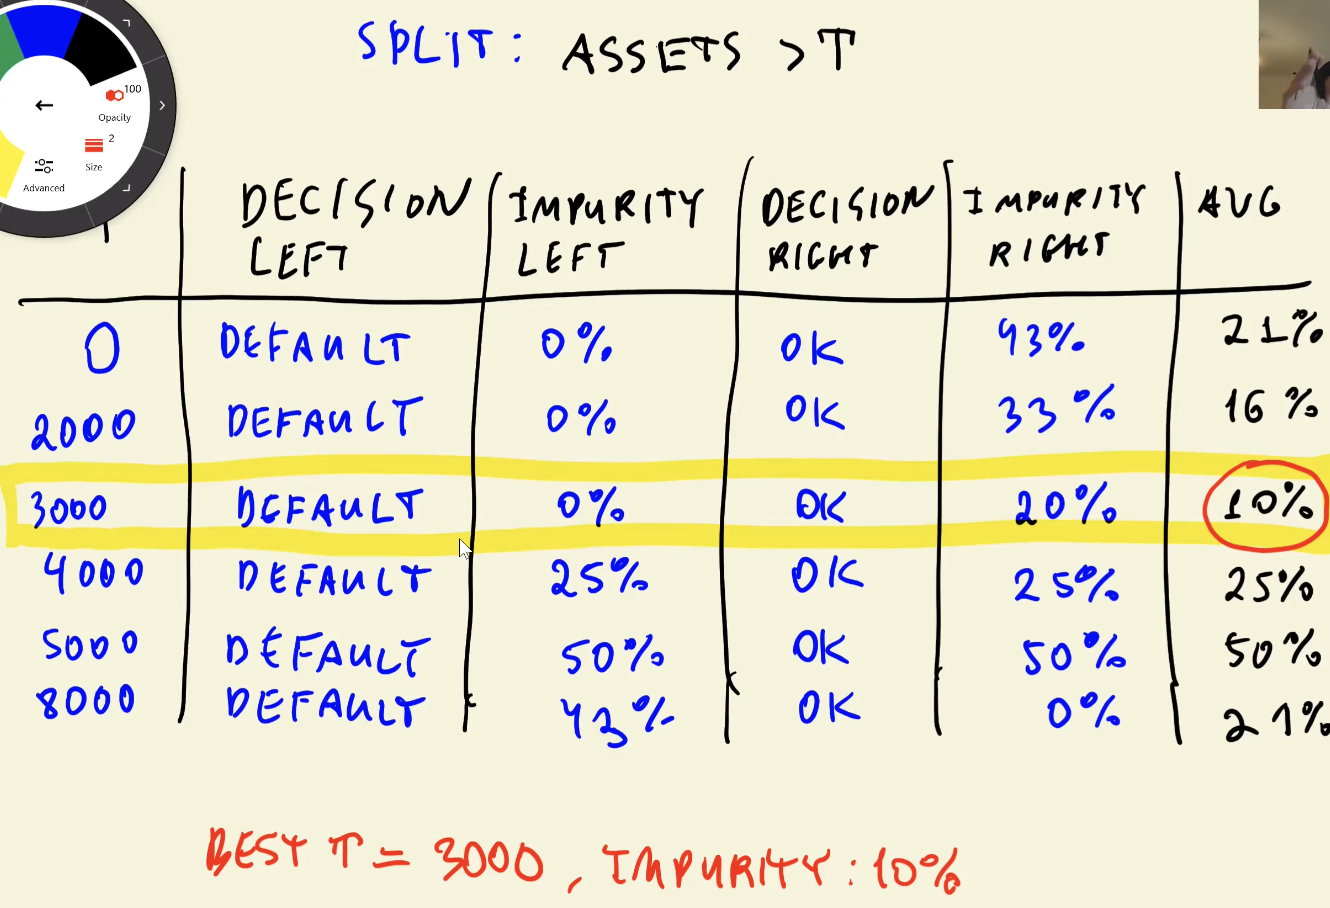